In [14]:

from langchain_groq import ChatGroq
from langchain_core.messages import BaseMessage, HumanMessage, SystemMessage
from langgraph.graph import StateGraph, START, END, MessagesState
from dotenv import load_dotenv
from langchain_core.tools import tool
from langgraph.checkpoint.postgres import PostgresSaver
import os   
from langchain_core.messages import trim_messages
from langchain_core.messages.utils import count_tokens_approximately

load_dotenv(override=True)
os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")
model = ChatGroq(model="openai/gpt-oss-120b")


In [15]:
MAX_TOKEN = 150

In [16]:
def call_model(state:MessagesState):


    messages = trim_messages(
        state["messages"],
        strategy="last",
        token_counter = count_tokens_approximately,
        max_tokens=MAX_TOKEN
    )

    print('current token count:', count_tokens_approximately(messages))

    for message in messages:
        print(message.content)

    response = model.invoke(messages)

    return {"messages" : [response]}

In [17]:
builder = StateGraph(MessagesState)
builder.add_node("call_model",call_model)
builder.add_edge(START,"call_model")

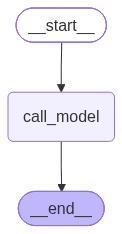

In [18]:
from langgraph.checkpoint.memory import InMemorySaver

checkpointer = InMemorySaver()
graph = builder.compile(checkpointer=checkpointer)
graph

In [20]:
config = {"configurable": {"thread_id": "chat-1"}}
result = graph.invoke(
    {"messages":[{"role":"user","content":"how are you my name is vijay"}]},
    config,
)

result["messages"][-1].content

current token count: 11
how are you my name is vijay


"Hello Vijay! I'm doing great, thanks for asking. How about you? Anything interesting going on today?"

In [22]:
result = graph.invoke(
    {"messages":[{"role":"user","content":"explain langchain all"}]},
    config,
)

result["messages"][-1].content

current token count: 10
explain langchain all


'## LangChain – A Complete Overview\n\nLangChain is an open‑source **framework for building applications that are powered by large language models (LLMs)**.  \nIt abstracts away the repetitive plumbing (prompt‑building, LLM calls, memory, tool use, etc.) so you can focus on the **logic of your product**—whether that’s a chatbot, a retrieval‑augmented generator, an autonomous agent, or any other LLM‑driven workflow.\n\nBelow is a **full‑stack walkthrough** of the main concepts, modules, and typical patterns you’ll encounter when using LangChain.\n\n---\n\n## 1. Core Philosophy\n\n| Goal | How LangChain Helps |\n|------|---------------------|\n| **Rapid prototyping** | Ready‑made wrappers for many LLM providers (OpenAI, Anthropic, Cohere, Azure, HuggingFace, etc.) |\n| **Composable building blocks** | Small, interchangeable pieces (prompts, chains, agents, memory) that can be combined like LEGO bricks |\n| **Extensibility** | Plug‑in your own models, vector stores, document loaders, call

In [24]:
result = graph.invoke(
    {"messages":[{"role":"user","content":"explain langgraph all"}]},
    config,
)

result["messages"][-1].content

current token count: 10
explain langgraph all


'## LangGraph – A Full‑Featured Overview  \n\nLangGraph is an **open‑source framework for building, orchestrating, and managing complex, state‑ful LLM (large‑language‑model) workflows**. It sits on top of LangChain (or any other LLM‑toolkit) and adds a graph‑oriented abstraction that makes it easy to:\n\n* **Compose** multiple LLM calls, tools, and custom logic into a single, reusable pipeline.  \n* **Persist & resume** long‑running or multi‑step conversations with built‑in state management.  \n* **Branch, loop, and converge** execution paths using a directed‑graph model (nodes\u202f↔\u202fedges).  \n* **Visualise** the workflow for debugging, monitoring, and documentation.  \n\nBelow is a **complete walk‑through** of the main concepts, architecture, API surface, and practical tips for using LangGraph effectively.\n\n---\n\n## 1️⃣ Core Concepts\n\n| Concept | What It Is | Typical Use |\n|---------|------------|-------------|\n| **Node** | A single unit of work – can be an LLM call, a t

In [26]:
result = graph.invoke(
    {"messages":[{"role":"user","content":"whats my name , my nam eis ivjay"}]},
    config,
)

result["messages"][-1].content

current token count: 48
whats my name
I don’t have any record of your name. Could you let me know what you’d like to be called?
whats my name , my nam eis ivjay


'Got it—your name is **Ivjay**. Nice to meet you! If there’s anything else you’d like to chat about, just let me know.'

In [28]:
result = graph.invoke(
    {"messages":[{"role":"user","content":"whats my name"}]},
    config,
)

result["messages"][-1].content

current token count: 91
whats my name
I don’t have any record of your name. Could you let me know what you’d like to be called?
whats my name , my nam eis ivjay
Got it—your name is **Ivjay**. Nice to meet you! If there’s anything else you’d like to chat about, just let me know.
whats my name


'Your name is **Ivjay**.'

In [31]:
result = graph.invoke(
    {"messages":[{"role":"user","content":"whats algorithm in 200 word"}]},
    config,
)

result["messages"][-1].content

current token count: 11
whats algorithm in 200 word


'An **algorithm** is a finite, step‑by‑step procedure for solving a specific problem or performing a computation. Think of it as a recipe: given an input, the algorithm follows a well‑defined sequence of instructions, each of which is unambiguous and executable, and eventually produces an output or reaches a stopping condition. Key properties include:\n\n1. **Finiteness** – It must terminate after a limited number of steps.  \n2. **Definiteness** – Every instruction is precisely described; there’s no room for interpretation.  \n3. **Input** – It can accept zero or more inputs from a defined set.  \n4. **Output** – It yields at least one result, transforming the input into useful information.  \n5. **Effectiveness** – Each step is simple enough to be carried out, in principle, by a human using pencil and paper or by a machine.\n\nAlgorithms are the backbone of computer science and everyday technology. For example, a sorting algorithm like **quick‑sort** rearranges a list of numbers into